## Data Collection, Cleaning & Descriptive Statistics
Rajesh Basnet S404205

Mini World Cup Predictor Project


Summary 

Analytical Question

Do teams that scored first have a different average number of full‑time corners than teams that didn’t score first?

In Week 1, I collected raw data from TheStatsDontLie (TSDL), cleaned the dataset, and performed descriptive statistics.

raw data → cleaning → final dataset → analysis.

# Raw Data Collection

The raw data was collected manually from:

https://www.thestatsdontlie.com/football/world-cup-2026/

Two tables were used:

# Table 1: Scored First
Columns:

Team

G (Games played)

SF (Games scored first)

% (Percentage of games scored first)

# Table 2: Full Time Corners For 
Columns:

Team

G (Games played)

FT CF (Total corners)

Avg (Average corners per match)

These raw tables contain extra columns that are not needed for our research question.

# Problems Identified in Raw Data
1. Extra columns present

- Scored First table: G, SF, %

- Corners table: G, FT CF, Avg

Only % and Avg are needed.

2. Percentage values contain “%”  

Must be cleaned and converted to numeric.

3. Team names appear in different order  

Requires merging and alignment.

4. Some teams appear in one table but not the other  

Must handle missing values (NaN).

5. No binary variable exists  

We need a variable to classify teams into:

1 = scored first (≥50%)

0 = didn’t score first (<50%)

6. Raw data is in Excel (.xlsx)  

Must convert to CSV for Python analysis.

# Convert to Excel to CSV

In [40]:
#Converted excel file into .csv for Python cleaning and analysis/better coding
# All data files sit in the same folder as this notebook, so I use plain file
# names with no folder in front. That way the notebook runs anywhere, including
# straight from the GitHub repo, without needing a Dataset folder to exist.
import pandas as pd

# Convert scored first
df_scored = pd.read_excel("Scored first.xlsx")
df_scored.to_csv("scored_first_raw.csv", index=False)

# Convert corners
df_corners = pd.read_excel("Full time corners for .xlsx")
df_corners.to_csv("Full time corner for.csv", index=False)


In [41]:
import pandas as pd

# Load raw data
# Fixed: corners/scored variables were swapped
scored_raw = pd.read_csv("scored_first_raw.csv")
corners_raw = pd.read_csv("Full time corner for.csv")

# print the dimensions of both DataFrames
print("Scored first (%.d rows and %.d columns.)" % (scored_raw.shape[0], scored_raw.shape[1]))
print("Corners (%.d rows and %.d columns.)" % (corners_raw.shape[0], corners_raw.shape[1]))

scored_raw.head() #display 5 result of table

Scored first (48 rows and 4 columns.)
Corners (48 rows and 4 columns.)


,Team,G,SF,%
0,Netherlands,4,4,1.00
1,Spain,8,7,0.88
2,Norway,6,5,0.83
3,Egypt,5,4,0.80
4,Mexico,5,4,0.80


# Data Cleaning 

In [42]:
import pandas as pd

# Load raw data
scored = pd.read_csv("scored_first_raw.csv")
corners = pd.read_csv("Full time corner for.csv")

#My  Actual column names:
# ['Team', 'G', 'SF', '%']

# Keep only Team and %
scored = scored[["Team", "%"]]

# Rename % to Percent
scored = scored.rename(columns={"%": "Percent"})

# Convert decimal values to percentages (1.00 → 100)
scored["Percent"] = scored["Percent"] * 100

# Keep only Team and Avg from corners
corners = corners[["Team", "Avg"]]

# Merge datasets
df = scored.merge(corners, on="Team", how="outer")

# Rename columns
df = df.rename(columns={
    "Percent": "Scored_First_Percent",
    "Avg": "FT_Corners_Avg"
})

# Create binary variable
df["Scored_First_Binary"] = df["Scored_First_Percent"].apply(
    lambda x: 1 if x >= 50 else 0
)

df


,Team,Scored_First_Percent,FT_Corners_Avg,Scored_First_Binary
0,Algeria,0.0,3.50,0
1,Argentina,63.0,4.00,1
2,Australia,25.0,4.00,0
3,Austria,50.0,2.50,1
4,Belgium,33.0,4.00,0
5,Bosnia and Herzegovina,50.0,3.75,1
6,Brazil,40.0,5.40,0
7,Canada,40.0,10.00,0
8,Cape Verde,25.0,2.75,0
9,Colombia,60.0,4.20,1


Check Dataset Structure

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Team                  48 non-null     str    
 1   Scored_First_Percent  48 non-null     float64
 2   FT_Corners_Avg        48 non-null     float64
 3   Scored_First_Binary   48 non-null     int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 1.6 KB


Check for Missing Values

In [44]:
df.isnull().sum()

Team                    0
Scored_First_Percent    0
FT_Corners_Avg          0
Scored_First_Binary     0
dtype: int64

# Descriptive Statistics

In [45]:
df.describe()

,Scored_First_Percent,FT_Corners_Avg,Scored_First_Binary
count,48.0000,48.000000,48.000000
mean,40.7500,4.228958,0.437500
std,29.4687,1.773761,0.501328
min,0.0000,1.600000,0.000000
25%,25.0000,3.000000,0.000000
50%,40.0000,4.000000,0.000000
75%,67.0000,4.910000,1.000000
max,100.0000,10.000000,1.000000


# Group Descriptive Statistics

In [46]:
# Split into two groups
scored_first = df[df["Scored_First_Binary"] == 1]["FT_Corners_Avg"]
did_not_score_first = df[df["Scored_First_Binary"] == 0]["FT_Corners_Avg"]

# Descriptive statistics
print("Teams that scored first:")
print("Mean:", scored_first.mean())
print("Median:", scored_first.median())
print("Std Dev:", scored_first.std())

print("\nTeams that did NOT score first:")
print("Mean:", did_not_score_first.mean())
print("Median:", did_not_score_first.median())
print("Std Dev:", did_not_score_first.std())


Teams that scored first:
Mean: 4.656666666666667
Median: 4.5
Std Dev: 1.2347077926915881

Teams that did NOT score first:
Mean: 3.8962962962962964
Median: 3.25
Std Dev: 2.0620474294107787



Teams that score first tend to generate more corners on average.

 Teams that do not score first generate fewer corners and show more variability.


In [47]:
# # Save output next to raw files
df.to_csv("scored first average corner cleaned data.csv", index=False)
print("Saved %s" % "scored first average corner cleaned data.csv")

Saved scored first average corner cleaned data.csv


# Population vs Sample

My dataset has 48 teams, which is every team that played in World Cup 2026. I still treat them as a **sample**, not as the whole population.

- **Population:** all national teams capable of qualifying for a World Cup, including past and future tournaments.
- **Sample:** the 48 teams that qualified for 2026.

This matters. If the 48 teams were the whole population, my mean would already be the true mean and there would be nothing left to estimate, so a confidence interval and a t-test would have no meaning.

**Limitation:** this is a convenience sample, not a simple random sample. Teams qualify by winning matches, so they are stronger than an average national team. My conclusion applies to World Cup level teams only.

# Sample Size of Each Group

The rule for choosing z* or t* depends on sample size, so I check the group sizes before doing any test.

In [48]:
# count how many teams are in each group
print(df["Scored_First_Binary"].value_counts())

n1 = len(scored_first)
n0 = len(did_not_score_first)
n_all = len(df)

print("\nGroup 1 - scored first: %d teams" % n1)
print("Group 0 - did not score first: %d teams" % n0)
print("Whole sample: %d teams" % n_all)

Scored_First_Binary
0    27
1    21
Name: count, dtype: int64

Group 1 - scored first: 21 teams
Group 0 - did not score first: 27 teams
Whole sample: 48 teams


The whole sample has 48 teams, which is 30 or more. Both groups on their own are under 30. I come back to this in the confidence interval section.

# Descriptive Statistics of the Response Variable

I used `describe()` above. Here I calculate each statistic separately, so I can explain every value.

In [49]:
import statistics as stats
import numpy as np

# extract the values as a numpy array (this excludes the column name)
sample = df.FT_Corners_Avg.values

# mean and median
x_bar = stats.mean(sample)
median = stats.median(sample)
print("Mean: %.4f. Median: %.4f." % (x_bar, median))

# range
the_range = np.max(sample) - np.min(sample)
print("Min: %.2f. Max: %.2f. Range: %.2f." % (np.min(sample), np.max(sample), the_range))

# sample variance and sample standard deviation
# ddof=1 gives the SAMPLE formula (divide by n-1).
# Without ddof=1 numpy uses the POPULATION formula (divide by n), which would
# be wrong here because I am treating the 48 teams as a sample.
s_square = sample.var(ddof=1)
s = sample.std(ddof=1)
print("Sample variance: %.4f. Sample std. dev.: %.4f." % (s_square, s))

Mean: 4.2290. Median: 4.0000.
Min: 1.60. Max: 10.00. Range: 8.40.
Sample variance: 3.1462. Sample std. dev.: 1.7738.


I did not calculate the mode. Average corners is continuous data, so almost every team has a different value and the mode tells me nothing useful.

The mean sits slightly above the median, which suggests some high values are pulling the distribution to the right. The outlier check below looks at that.

# Outlier Check (1.5 x IQR Rule)

Outliers pull the mean and inflate the standard deviation, so I check for them before the t-test.

In [50]:
# iqr and percentiles
pct25 = np.percentile(sample, 25)
pct75 = np.percentile(sample, 75)
iqr = pct75 - pct25
print("IQR: %.2f. 25th percentile: %.2f. 75th percentile: %.2f" % (iqr, pct25, pct75))

# 1.5 x IQR rule
lower_fence = pct25 - 1.5 * iqr
upper_fence = pct75 + 1.5 * iqr
print("Outlier fences: below %.2f or above %.2f" % (lower_fence, upper_fence))

# find the teams outside the fences
outliers = df[(df["FT_Corners_Avg"] < lower_fence) | (df["FT_Corners_Avg"] > upper_fence)]
print("Number of outliers: %d" % len(outliers))
outliers

IQR: 1.91. 25th percentile: 3.00. 75th percentile: 4.91
Outlier fences: below 0.13 or above 7.78
Number of outliers: 2


,Team,Scored_First_Percent,FT_Corners_Avg,Scored_First_Binary
7,Canada,40.0,10.00,0
46,Uruguay,0.0,8.67,0


Two teams are outliers: **Canada (10.00)** and **Uruguay (8.67)**. Both are in group 0, the teams that did NOT score first in most of their matches.

I **kept** both. They are real results, not typing mistakes — Canada is a host nation and Uruguay is a strong team, so the numbers are believable. Removing a team only because its value is high would change my answer for the wrong reason. I run the test again without them later as a sensitivity check.

# Visualisation

A histogram shows the shape of the distribution. This is also how I check the normality assumption for the t-test.

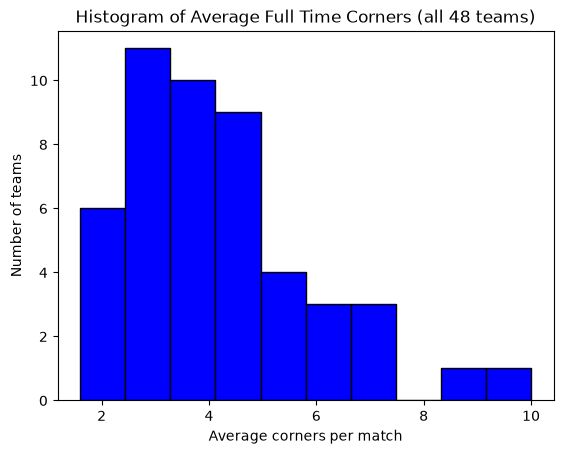

In [51]:
import matplotlib.pyplot as plt

# plot histogram of the distribution of average corners
plt.hist(sample, color='blue', edgecolor='black', bins=10)
plt.title("Histogram of Average Full Time Corners (all 48 teams)")
plt.xlabel("Average corners per match")
plt.ylabel("Number of teams")
plt.show()

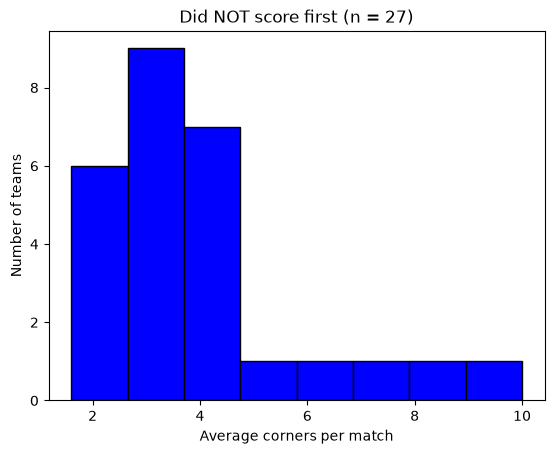

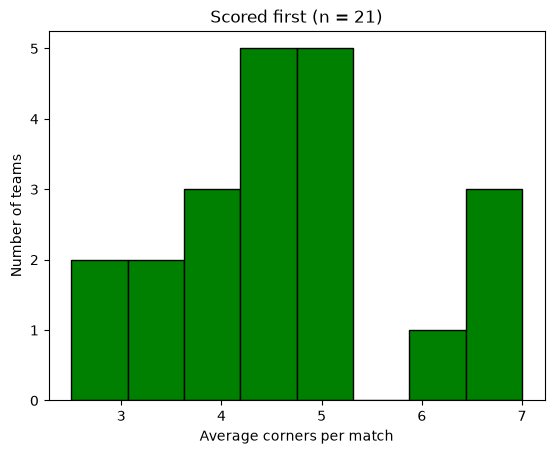

In [52]:
# same histogram but split into the two groups, so I can compare them
plt.hist(did_not_score_first, color='blue', edgecolor='black', bins=8)
plt.title("Did NOT score first (n = %d)" % n0)
plt.xlabel("Average corners per match")
plt.ylabel("Number of teams")
plt.show()

plt.hist(scored_first, color='green', edgecolor='black', bins=8)
plt.title("Scored first (n = %d)" % n1)
plt.xlabel("Average corners per match")
plt.ylabel("Number of teams")
plt.show()

The two groups do not have the same shape, so I need to be careful rather than just claiming the data looks normal.

**Group 1 (scored first):** most teams sit between 4 and 5.5, with a small separate group around 6.5 to 7. No long tail, so reasonably balanced.

**Group 0 (did not score first):** clearly skewed to the right. Most teams are packed between 2 and 4.5, then a flat tail of single teams runs out to 10, where Canada and Uruguay sit.

Week 4 says a t-test on data that does not appear normal can still be used, but the p-value may only be approximately accurate. That is my situation, so I treat my p-value as approximate. The skew also explains why group 0's standard deviation is 2.06 against group 1's 1.23.

# Confidence Interval

A sample mean will almost never equal the population mean exactly. A confidence interval gives a range of likely values for it.

Formula from Week 3:

**CI = x̄ ± z\* · (s / √n)**   where s/√n is the **standard error** and z\* · s/√n is the **margin of error**.

Week 3 states the formula assumes n is 30 or greater, because it depends on the Central Limit Theorem. My whole sample has 48 teams, so the condition is met. I follow the two methods from the Week 3 practical: step by step, then statsmodels as a check.

In [53]:
import scipy.stats as st
import math

# Method 1: Step-by-step calculation
# sample mean, standard deviation, and sample size
x_bar = st.tmean(sample)
s = st.tstd(sample)
n = len(sample)
print("Mean: %.4f. Standard deviation: %.4f. Size: %d." % (x_bar, s, n))

# z-score (assuming 95% Confidence Level)
z_score = st.norm.ppf(q = 0.975)
print("Z-statistic: %.3f" % z_score)

# compute standard error
std_err = s / math.sqrt(n)
print("Standard error: %.4f" % std_err)

# compute the margin of error
mrg_err = z_score * std_err
print("Margin of error: %.4f" % mrg_err)

# get the lower and upper bound of confidence interval
ci_low = x_bar - mrg_err
ci_upp = x_bar + mrg_err

print("Confidence Interval of the mean: %.4f to %.4f" % (ci_low, ci_upp))

Mean: 4.2290. Standard deviation: 1.7738. Size: 48.
Z-statistic: 1.960
Standard error: 0.2560
Margin of error: 0.5018
Confidence Interval of the mean: 3.7272 to 4.7307


In [54]:
# Method 2: Use the statsmodels package
import statsmodels.stats.weightstats as stm

ci_low_stm, ci_upp_stm = stm._zconfint_generic(x_bar, std_err, alpha=0.05, alternative="two-sided")
print("Confidence Interval of the mean: %.4f to %.4f" % (ci_low_stm, ci_upp_stm))

Confidence Interval of the mean: 3.7272 to 4.7307


Both methods give the same answer, so my step by step calculation is correct.

I am 95% confident the true mean for World Cup level teams falls inside this interval. More precisely, the 95% describes the method: if I repeated this many times, about 95% of the intervals I built would contain the true mean.

## A Confidence Interval for Each Group

I also wanted an interval per group so I could compare them side by side.

Group 1 has 21 teams and group 0 has 27, both under 30, so the Week 3 z\* formula does not apply to them. Week 4 explains why: once the unknown sigma is replaced by s from a small sample, the sample means no longer follow the standard normal distribution and a t-distribution is needed. So I replace z\* with t\*, using df = n - 1.

This is my own extension. Week 3 teaches z\* intervals and Week 4 introduces the t-distribution for testing. The whole-sample interval above stays my official answer.

In [55]:
# 95% confidence interval for each group, using t* instead of z*
def group_conf_interval(group_sample, group_name):
    x_bar = st.tmean(group_sample)
    s = st.tstd(group_sample)
    n = len(group_sample)

    std_err = s / math.sqrt(n)

    # t-score instead of z-score, because n < 30
    t_score = st.t.ppf(q = 0.975, df = n - 1)
    mrg_err = t_score * std_err

    ci_low = x_bar - mrg_err
    ci_upp = x_bar + mrg_err

    print(group_name)
    print("\t Mean: %.4f. Standard deviation: %.4f. Size: %d." % (x_bar, s, n))
    print("\t T-statistic: %.4f (df = %d)" % (t_score, n - 1))
    print("\t Standard error: %.4f. Margin of error: %.4f." % (std_err, mrg_err))
    print("\t Confidence Interval of the mean: %.4f to %.4f\n" % (ci_low, ci_upp))

    return ci_low, ci_upp

ci_group1 = group_conf_interval(scored_first, "Group 1 - scored first")
ci_group0 = group_conf_interval(did_not_score_first, "Group 0 - did not score first")

Group 1 - scored first
	 Mean: 4.6567. Standard deviation: 1.2347. Size: 21.
	 T-statistic: 2.0860 (df = 20)
	 Standard error: 0.2694. Margin of error: 0.5620.
	 Confidence Interval of the mean: 4.0946 to 5.2187

Group 0 - did not score first
	 Mean: 3.8963. Standard deviation: 2.0620. Size: 27.
	 T-statistic: 2.0555 (df = 26)
	 Standard error: 0.3968. Margin of error: 0.8157.
	 Confidence Interval of the mean: 3.0806 to 4.7120



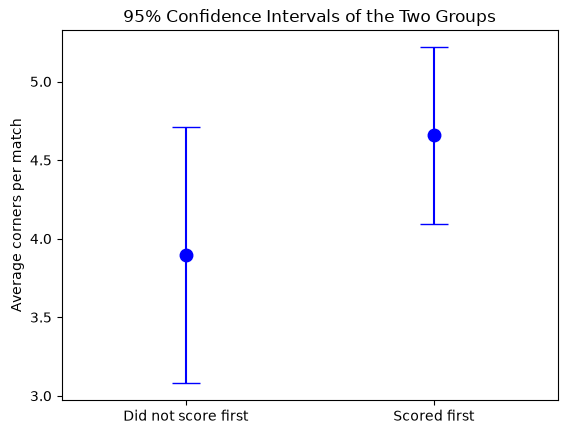

In [56]:
# plot the two intervals so they are easy to compare
means = [did_not_score_first.mean(), scored_first.mean()]
errors = [means[0] - ci_group0[0], means[1] - ci_group1[0]]

plt.errorbar([0, 1], means, yerr=errors, fmt='o', color='blue', capsize=10, markersize=9)
plt.xticks([0, 1], ["Did not score first", "Scored first"])
plt.xlim(-0.5, 1.5)
plt.title("95% Confidence Intervals of the Two Groups")
plt.ylabel("Average corners per match")
plt.show()

The two intervals overlap a lot, which is already a sign the difference may not be significant. The t-test below tests it properly.

# Two-Sample t-Test

The confidence intervals describe each group. Now I test the question itself: is the gap between the groups bigger than random sampling could produce by chance? I use the 4 step process from Week 4.

## Step 1 - State

Do teams that scored first in the majority of their matches have a different average number of full time corners than teams that did not?

## Step 2 - Plan

Parameters:

- μ₁ = mean average corners for teams that scored first in most of their matches
- μ₀ = mean average corners for teams that did not

Hypotheses:

- **H₀: μ₁ = μ₀** (no difference between the two groups)
- **Hₐ: μ₁ ≠ μ₀** (there is a difference)

I use a two sided test because both directions are possible. A team that takes the lead might keep attacking and win more corners, or it might sit back to defend the lead and win fewer corners. I have no reason to assume only one of these before testing.

Test: **two-sample t-test** (also called independent t-test). I have two independent groups of teams, each team is in only one group, and I do not know the population standard deviations.

Significance level: **α = 0.05**. I reject H₀ if p ≤ 0.05.

In [57]:
# Step 3 - Solve
# (a) Check the sampling procedure. The 48 teams are treated as a sample of
#     World Cup level teams. It is a convenience sample and not a simple random
#     sample, which I stated as a limitation in the Population vs Sample section.
# (b) Check normality. I did this with the histograms above. Group 1 is
#     reasonably balanced. Group 0 is skewed to the right with a long tail
#     out to 10 corners, so it is NOT normal. Week 4 says the t-test can
#     still be used in that case, but the p-value is only approximately
#     accurate. I treat my p-value that way.
# (c) Calculate the basic statistics of the two samples.

# the basic statistics of sample 1 (teams that scored first):
x_bar1 = st.tmean(scored_first)
s1 = st.tstd(scored_first)
n1 = len(scored_first)

# the basic statistics of sample 2 (teams that did not score first):
x_bar2 = st.tmean(did_not_score_first)
s2 = st.tstd(did_not_score_first)
n2 = len(did_not_score_first)

print("Sample 1 - scored first")
print("\t Mean: %.4f. Standard deviation: %.4f. Size: %d." % (x_bar1, s1, n1))
print("Sample 2 - did not score first")
print("\t Mean: %.4f. Standard deviation: %.4f. Size: %d." % (x_bar2, s2, n2))
print("\nDifference between the means: %.4f corners per match" % (x_bar1 - x_bar2))

Sample 1 - scored first
	 Mean: 4.6567. Standard deviation: 1.2347. Size: 21.
Sample 2 - did not score first
	 Mean: 3.8963. Standard deviation: 2.0620. Size: 27.

Difference between the means: 0.7604 corners per match


In [58]:
# Step 3 (d) - compute the t-statistic by hand, using the Week 4 formula
# t* = (x_bar1 - x_bar2) / sqrt( s1^2/n1 + s2^2/n2 )

numerator = x_bar1 - x_bar2
denominator = math.sqrt((s1 ** 2 / n1) + (s2 ** 2 / n2))
t_star = numerator / denominator

print("\n Computing t* ...")
print("\t numerator (difference between the means): %.4f" % numerator)
print("\t denominator (standard error of the difference): %.4f" % denominator)
print("\t t-statistic (t*): %.4f" % t_star)


 Computing t* ...
	 numerator (difference between the means): 0.7604
	 denominator (standard error of the difference): 0.4797
	 t-statistic (t*): 1.5852


In [59]:
# Step 3 (e) - compute the p-value.
# Week 4 uses the conservative approach for the degrees of freedom: the samples
# have df of n1-1 and n2-1, and we select the SMALLER one. This gives a slightly
# bigger p-value, so I am less likely to claim a difference that is not there.

df_conservative = min(n1, n2) - 1
p_val = 2 * (1 - st.t.cdf(abs(t_star), df_conservative))

print("\n Computing p-value ...")
print("\t degrees of freedom: %d and %d, conservative choice is %d"
      % (n1 - 1, n2 - 1, df_conservative))
print("\t p-value: %.4f" % p_val)


 Computing p-value ...
	 degrees of freedom: 20 and 26, conservative choice is 20
	 p-value: 0.1286


In [60]:
# check my hand calculation using the scipy functions from the Week 4 practical.
# note the argument equal_var=False, which assumes that two populations do not
# have equal variance. This matches the formula I used above.

t_stats_a, p_val_a = st.ttest_ind_from_stats(x_bar1, s1, n1, x_bar2, s2, n2,
                                             equal_var=False, alternative='two-sided')
t_stats_b, p_val_b = st.ttest_ind(scored_first, did_not_score_first,
                                  equal_var=False, alternative='two-sided')

print("\t My calculation      -> t*: %.4f, p-value: %.4f" % (t_star, p_val))
print("\t ttest_ind_from_stats-> t*: %.4f, p-value: %.4f" % (t_stats_a, p_val_a))
print("\t ttest_ind           -> t*: %.4f, p-value: %.4f" % (t_stats_b, p_val_b))

	 My calculation      -> t*: 1.5852, p-value: 0.1286
	 ttest_ind_from_stats-> t*: 1.5852, p-value: 0.1202
	 ttest_ind           -> t*: 1.5852, p-value: 0.1202


The t* value is identical in all three. Scipy's p-value is slightly smaller because it uses a more precise degrees of freedom calculation, while I used the conservative smaller-sample rule from Week 4. Both lead to the same decision.

In [61]:
# Step 4 - Conclude
print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
    print("\t There is a significant difference between the two groups.")
else:
    print("\t We accept the null hypothesis.")
    print("\t There is not enough evidence to say the two groups have a")
    print("\t different average number of corners.")

print("\n\t Observed difference: %.4f corners per match" % (x_bar1 - x_bar2))


 Conclusion:
	 We accept the null hypothesis.
	 There is not enough evidence to say the two groups have a
	 different average number of corners.

	 Observed difference: 0.7604 corners per match


# Sensitivity Check

Earlier I found two outliers and kept them. Here I run the same test without them, only to see how much they matter. This is not my final result.

In [62]:
# remove the two outlier teams and run the same test again
df_no_outliers = df[~df["Team"].isin(["Canada", "Uruguay"])]

group1_no = df_no_outliers[df_no_outliers["Scored_First_Binary"] == 1]["FT_Corners_Avg"]
group2_no = df_no_outliers[df_no_outliers["Scored_First_Binary"] == 0]["FT_Corners_Avg"]

t_stats_no, p_val_no = st.ttest_ind(group1_no, group2_no,
                                    equal_var=False, alternative='two-sided')

print("WITHOUT Canada and Uruguay")
print("\t Sample 1 mean: %.4f. Size: %d." % (st.tmean(group1_no), len(group1_no)))
print("\t Sample 2 mean: %.4f. Size: %d." % (st.tmean(group2_no), len(group2_no)))
print("\t t-statistic (t*): %.4f" % t_stats_no)
print("\t p-value: %.4f" % p_val_no)

WITHOUT Canada and Uruguay
	 Sample 1 mean: 4.6567. Size: 21.
	 Sample 2 mean: 3.4612. Size: 25.
	 t-statistic (t*): 3.0982
	 p-value: 0.0034


Without those two teams the p-value drops below 0.05 and the result becomes significant.

So **my result is not stable**. Two teams out of 48 are enough to change the conclusion, which means my sample is too small to answer this confidently. I report the result **with** the outliers included — removing real data points just to get a significant p-value would not be correct.

# Conclusion

Teams that scored first in most of their matches averaged more corners than teams that did not, but the difference was not significant at the 5% level, so I accept the null hypothesis.

In football terms, I did not find clear evidence that taking the lead changes how much pressure a team keeps applying. Leading teams won slightly more corners, but the gap is small enough that random variation could explain it. Accepting H₀ does not prove the groups are the same — it means 48 teams is too few to detect a difference this small.

Group 0 is skewed rather than normal, so following Week 4 my p-value is approximate. It is nowhere near the 0.05 line, so this does not change my decision.

One pattern worth noting: the two teams with the most corners, Canada and Uruguay, were both in the group that did **not** score first. That supports the idea that corners measure pressure rather than quality — a team can keep attacking without scoring first.

# Lessons Learned

1. **The question has to match the data I actually have.** My data gives a percentage of matches where a team scored first, not a result per match, so the correct question is about teams that scored first in the *majority* of their matches. I reworded my question to match.

2. **Outliers can decide the answer.** Removing two teams out of 48 changed my result from not significant to significant. I used to think a p-value was a fixed answer; now I see how much it depends on the sample.

3. **The z\* formula comes with a condition attached.** Week 3 assumes n is 30 or more. My whole sample of 48 is fine, but my groups of 21 and 27 are not, so the formula does not apply to them. I would previously have used it without checking.

4. **ddof=1 matters.** NumPy uses the population formula by default. Because the 48 teams are a sample, I need ddof=1 — without it my standard deviation would be too small and my interval too narrow.

5. **Checking my work two ways is worth the time.** Every statistic was calculated once by formula and once by a library function. When both agreed I knew the formula was right, not just my typing.

# Limitations

- Convenience sample, not a simple random sample — the 48 teams qualified by being strong.
- Team level averages, so match to match variation inside each team is lost.
- Teams played between 3 and 8 matches, so a 3-match average is far less reliable than an 8-match one.
- The 50% cut point is my own choice: 2 out of 3 and 3 out of 3 land in the same group.
- Group 0 is right skewed rather than normal, so the p-value is approximate. A match-level dataset would give a more reliable answer.